# **CVaR-Based Left-Tail Factor Strategy with Robustness & Regime-Switching Extension**

## *Min Seo Kim, Hannah Lee, Yize Liu, Hao Jing, Venktesh Bohra, Arjun Deshmukh*

### 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
warnings.filterwarnings('ignore')

### 2. Data Preprocessing

#### 2.1. Daily CRSP Data

In [3]:
# Load the full CRSP stock file
df_daily = pd.read_feather('data/crsp_2015_2024.feather')

# Convert date column to datetime format
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Keep only common shares (SHRCD = 10 or 11)
df_daily = df_daily[df_daily['SHRCD'].isin([10, 11])]

# Keep only stocks traded on NYSE (1), AMEX (2), or NASDAQ (3)
df_daily = df_daily[df_daily['EXCHCD'].isin([1, 2, 3])]

# Sort by PERMNO and date for a clean time series
df_daily = df_daily.sort_values(['PERMNO', 'date']).reset_index(drop=True)

# Choose which return to use for risk estimation
# Here, we use RETX (price-only return, excluding dividends) for backtesting purpose
df_daily['daily_ret'] = pd.to_numeric(df_daily['RETX'], errors='coerce')

# Drop rows where return is missing
df_daily = df_daily.dropna(subset=['daily_ret'])

# Create monthly identifier (e.g., 2020-01, 2020-02, ...)
df_daily['month'] = df_daily['date'].dt.to_period('M')

# Keep relevant columns
df_daily = df_daily[['PERMNO', 'date', 'month', 'daily_ret']].copy()

In [4]:
df_daily

,PERMNO,date,month,daily_ret
0,10001,2015-01-02,2015-01,0.0
1,10001,2015-01-05,2015-01,0.0
2,10001,2015-01-06,2015-01,-0.010889
3,10001,2015-01-07,2015-01,0.001835
4,10001,2015-01-08,2015-01,0.005494
...,...,...,...,...
9661071,93436,2024-12-24,2024-12,0.073572
9661072,93436,2024-12-26,2024-12,-0.01763
9661073,93436,2024-12-27,2024-12,-0.049479
9661074,93436,2024-12-30,2024-12,-0.033012


#### 2.2. Monthly CRSP Data

In [5]:
# Compute realized monthly return for each stock:
# (1 + daily_ret) product over all days in the month minus 1
df_monthly = (
    df_daily.groupby(['PERMNO', 'month'])['daily_ret']
            .apply(lambda x: (1 + x).prod() - 1)
            .reset_index(name='monthly_ret')
)

# Sort by stock and month before shifting
df_monthly = df_monthly.sort_values(['PERMNO', 'month'])

# For each stock, create the NEXT month's return (future payoff for the signal)
df_monthly['monthly_ret_next'] = (
    df_monthly.groupby('PERMNO')['monthly_ret'].shift(-1)
)

In [6]:
df_monthly

,PERMNO,month,monthly_ret,monthly_ret_next
0,10001,2015-01,-0.115246,0.035898
1,10001,2015-02,0.035898,-0.013861
2,10001,2015-03,-0.013861,0.011044
3,10001,2015-04,0.011044,-0.006951
4,10001,2015-05,-0.006951,0.030000
...,...,...,...,...
463064,93436,2024-08,-0.077390,0.221945
463065,93436,2024-09,0.221945,-0.045025
463066,93436,2024-10,-0.045025,0.381468
463067,93436,2024-11,0.381468,0.170010


#### 2.3. Fama-MacBeth Data

In [7]:
# Load monthly Fama-MacBeth data
fmb_data = pd.read_feather('data/fmb_logmcap_bm.feather')

# Rename date column for consistency
fmb_data.rename(columns={'DATE': 'date'}, inplace=True)

# Convert PERMNO column to integer
fmb_data['PERMNO'] = fmb_data['PERMNO'].astype(int)

# Covert date column to datetime format
fmb_data['date'] = pd.to_datetime(fmb_data['date'])

# Offset date column to end of month
fmb_data['date'] = fmb_data['date'] + pd.offsets.MonthEnd(0)

In [8]:
# Load monthly Fama-MacBeth data
op_data = pd.read_feather('data/fmb_roe_op.feather')

# Reset multiindex column
op_data.reset_index(inplace=True)

# Rename data column for consistency
op_data.rename(columns={'DATE': 'date'}, inplace=True)

# Convert PERMNO column to integer
op_data['PERMNO'] = op_data['PERMNO'].astype(int)

# Covert date column to datetime format
op_data['date'] = pd.to_datetime(op_data['date'])

# Offset date column to end of month
op_data['date'] = op_data['date'] + pd.offsets.MonthEnd(0)

# Keep relevant columns
op_data = op_data[['PERMNO', 'date', 'OP']]

In [9]:
# Set PERMNO and date as index
fmb_data = fmb_data.set_index(['PERMNO', 'date']).sort_index()
op_data = op_data.set_index(['PERMNO', 'date']).sort_index()

# Merge with forward fill within each PERMNO group
fmb_data = fmb_data.join(op_data, how='left')

# Forward fill OP values for each stock
fmb_data['OP'] = fmb_data.groupby(level='PERMNO')['OP'].ffill()

# Reset index back to columns
fmb_data = fmb_data.reset_index()

In [10]:
# Construct momentum characteristic
mom_data = df_monthly[['PERMNO', 'month', 'monthly_ret']].copy()

# Sort by PERMNO and month
mom_data = mom_data.sort_values(['PERMNO', 'month'])

# Calculate 11-month rolling cumulative return
mom_data['MOM'] = (
    mom_data.groupby('PERMNO')['monthly_ret']
            .rolling(window=11, min_periods=11)
            .apply(lambda x: (1 + x).prod() - 1, raw=True)
            .reset_index(level=0, drop=True)
)

# Shift by 1 to get t-12 to t-2 (skip t-1)
mom_data['MOM'] = mom_data.groupby('PERMNO')['MOM'].shift(2)

# Convert month to date format for merging
mom_data['date'] = pd.to_datetime(mom_data['month'].astype(str)) + pd.offsets.MonthEnd(0)

# Merge with fmb data
fmb_data = pd.merge(
    fmb_data,
    mom_data[['PERMNO', 'date', 'MOM']],
    on=['PERMNO', 'date'],
    how='left'
)

In [11]:
fmb_data

,PERMNO,date,RET_RF_T1,LOG_MCAP,BM,OP,MOM
0,10001,1988-06-30,0.024900,-1.360123,0.394318,NaN,NaN
1,10001,1988-07-31,0.023226,-1.354949,0.405377,NaN,NaN
2,10001,1988-08-31,-0.027332,-1.320679,0.424894,NaN,NaN
3,10001,1988-09-30,0.033116,-1.335180,0.581824,NaN,NaN
4,10001,1988-10-31,-0.005700,-1.300024,0.621771,NaN,NaN
...,...,...,...,...,...,...,...
1786858,93436,2024-07-31,-0.082190,2.584209,-0.838138,0.072232,-0.319708
1786859,93436,2024-08-31,0.217942,2.532616,-0.863776,0.072232,-0.260068
1786860,93436,2024-09-30,-0.048925,2.602307,-0.798095,0.037328,-0.100781
1786861,93436,2024-10-31,0.377469,2.591161,-0.767563,0.037328,-0.144311


#### 2.4. Fama-French Data

In [12]:
# Load monthly Fama-French 5 factor data
ff_data = pd.read_csv('data/fama_french_5_factor.csv', index_col=0, parse_dates=True)

# Convert index column to datetime format
ff_data.index = pd.to_datetime(ff_data.index, format='%Y%m')

# Offest index column to end of month
ff_data.index = ff_data.index + pd.offsets.MonthEnd(0)

# Convert percentage returns to decimal returns
ff_data = ff_data / 100

# Calculate market returns
ff_data['Mkt'] = ff_data['Mkt-RF'] + ff_data['RF']

# Reest index column and rename it 'date'
ff_data.reset_index(names='date', inplace=True)

In [13]:
# Load monthly momentum factor data
mom_data = pd.read_csv('data/fama_french_mom_factor.csv', index_col=0, parse_dates=True)

# Convert index column to datetime format
mom_data.index = pd.to_datetime(mom_data.index, format='%Y%m')

# Offset index column to end of month
mom_data.index = mom_data.index + pd.offsets.MonthEnd(0)

# Convert percentage returns to decimal returns
mom_data = mom_data / 100

# Reset index column and rename it 'date'
mom_data.reset_index(names='date', inplace=True)

In [14]:
# Merge Fama-French 5 factor and momentum factor
ff_data = pd.merge(ff_data, mom_data, on='date', how='inner')

In [15]:
ff_data

,date,Mkt-RF,SMB,HML,RMW,CMA,RF,Mkt,MOM
0,1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,-0.0012,0.0101
1,1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0533,0.0100
2,1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,-0.0130,0.0012
3,1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0283,0.0313
4,1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0059,-0.0078
...,...,...,...,...,...,...,...,...,...
742,2025-05-31,0.0606,-0.0072,-0.0288,0.0129,0.0251,0.0038,0.0644,0.0221
743,2025-06-30,0.0486,-0.0002,-0.0160,-0.0320,0.0145,0.0034,0.0520,-0.0264
744,2025-07-31,0.0198,-0.0015,-0.0127,-0.0029,-0.0208,0.0034,0.0232,-0.0096
745,2025-08-31,0.0185,0.0488,0.0442,-0.0068,0.0207,0.0038,0.0223,-0.0354


### 3. CVaR Factor

#### 3.1. Compute Rolling CVaR(5%) Over 252 Days

In [16]:
def rolling_cvar(x, alpha=0.05):
    """
    Historical CVaR estimator

    x      : array of past returns (e.g., last 252 daily returns)
    alpha  : tail probability (0.05 = worst 5%)

    Returns the average of the worst alpha% observations
    """
    x_sorted = np.sort(x)                      # Sort ascending: most negative first
    k = int(np.floor(alpha * len(x_sorted)))
    if k == 0:
        return np.nan                          # If not enough data in the window
    return x_sorted[:k].mean()                 # Mean of the worst k returns

In [17]:
# Make a copy of dataframe
cvar_daily = df_daily.copy()

# Apply 252-day rolling CVaR per stock (PERMNO)
# min_periods=252 enforces that we only start computing CVaR once we have a full 252 trading days of history
cvar_daily['cvar_5'] = (
    cvar_daily.groupby('PERMNO')['daily_ret']
              .rolling(window=252, min_periods=252)
              .apply(rolling_cvar, kwargs={'alpha': 0.05}, raw=True)
              .reset_index(level=0, drop=True)
)

In [18]:
cvar_daily.iloc[250:260]

,PERMNO,date,month,daily_ret,cvar_5
250,10001,2015-12-30,2015-12,-0.006536,NaN
251,10001,2015-12-31,2015-12,-0.019737,-0.045243
252,10001,2016-01-04,2016-01,0.009396,-0.045243
253,10001,2016-01-05,2016-01,-0.013298,-0.045243
254,10001,2016-01-06,2016-01,0.014825,-0.045243
255,10001,2016-01-07,2016-01,0.014608,-0.045243
256,10001,2016-01-08,2016-01,0.019634,-0.045243
257,10001,2016-01-11,2016-01,0.03466,-0.045243
258,10001,2016-01-12,2016-01,0.023573,-0.045243
259,10001,2016-01-13,2016-01,0.0,-0.045243


#### 3.2. Construct TailScore From CVaR

In [19]:
# TailScore is defined as -CVaR
# Higher TailScore ⇒ more severe downside tail (worse tails)
cvar_daily['tail_score'] = -cvar_daily['cvar_5']

#### 3.3. Month-End Snapshot of TailScore per Stock

In [20]:
# For each stock and month, keep only the last trading day of that month
# This gives us the month-end TailScore used to form next month's portfolio
cvar_monthly = (
    cvar_daily.sort_values(['PERMNO', 'date'])
              .groupby(['PERMNO', 'month'])
              .tail(1)
              .copy()
)

# Drop month-end rows where TailScore is still NaN (this happens for the first 252 trading days of each stock's history)
cvar_monthly = cvar_monthly.dropna(subset=['tail_score'])

# Offset date to end of month
cvar_monthly['date'] = cvar_monthly['date'] + pd.offsets.MonthEnd(0)

#### 3.4. Align Next-Month Return

In [21]:
# Merge month-end TailScore snapshot with next month's return
# Each row now represents: stock i, month t, TailScore_t, and return_{t+1}
cvar_panel = cvar_monthly.merge(
    df_monthly[['PERMNO', 'month', 'monthly_ret', 'monthly_ret_next']],
    on=['PERMNO', 'month'],
    how='left'
)

# Drop rows where we don't observe the next month's return
cvar_panel = cvar_panel.dropna(subset=['monthly_ret_next'])

In [22]:
cvar_panel

,PERMNO,date,month,daily_ret,cvar_5,tail_score,monthly_ret,monthly_ret_next
0,10001,2015-12-31,2015-12,-0.019737,-0.045243,0.045243,-0.147598,0.116779
1,10001,2016-01-31,2016-01,0.014634,-0.042980,0.042980,0.116779,-0.055287
2,10001,2016-02-29,2016-02,0.002551,-0.045755,0.045755,-0.055287,-0.006361
3,10001,2016-03-31,2016-03,-0.010139,-0.045755,0.045755,-0.006361,-0.065301
4,10001,2016-04-30,2016-04,-0.004093,-0.049255,0.049255,-0.065301,-0.021919
...,...,...,...,...,...,...,...,...
391073,93436,2024-07-31,2024-07,0.042449,-0.071253,0.071253,0.172781,-0.077390
391074,93436,2024-08-31,2024-08,0.037958,-0.073446,0.073446,-0.077390,0.221945
391075,93436,2024-09-30,2024-09,0.004492,-0.076264,0.076264,0.221945,-0.045025
391076,93436,2024-10-31,2024-10,-0.029897,-0.075832,0.075832,-0.045025,0.381468


### 4. Volatility Benchmark

#### 4.1. Compute Rolling Standard Deviation Over 252 Days

In [23]:
# Make a copy of dataframe
vol_daily = df_daily.copy()

# Apply 252-day rolling standard deviation per stock (PERMNO)
# min_periods=252 enforces that we only start computing CVaR once we have a full 252 trading days of history
vol_daily['vol'] = (
    cvar_daily.groupby('PERMNO')['daily_ret']
              .rolling(window=252, min_periods=252)
              .std()
              .reset_index(level=0, drop=True)
)

In [24]:
vol_daily.iloc[250:260]

,PERMNO,date,month,daily_ret,vol
250,10001,2015-12-30,2015-12,-0.006536,NaN
251,10001,2015-12-31,2015-12,-0.019737,0.018721
252,10001,2016-01-04,2016-01,0.009396,0.018733
253,10001,2016-01-05,2016-01,-0.013298,0.018748
254,10001,2016-01-06,2016-01,0.014825,0.018766
255,10001,2016-01-07,2016-01,0.014608,0.018791
256,10001,2016-01-08,2016-01,0.019634,0.018833
257,10001,2016-01-11,2016-01,0.03466,0.018964
258,10001,2016-01-12,2016-01,0.023573,0.018998
259,10001,2016-01-13,2016-01,0.0,0.018957


#### 4.2. Month-End Snapshot of Volatility per Stock

In [25]:
# For each stock and month, keep only the last trading day of that month
# This gives us the month-end volatility used to form next month's portfolio
vol_monthly = (
    vol_daily.sort_values(['PERMNO', 'date'])
             .groupby(['PERMNO', 'month'])
             .tail(1)
             .copy()
)

# Drop month-end rows where volatility is still NaN (this happens for the first 252 trading days of each stock's history)
vol_monthly = vol_monthly.dropna(subset=['vol'])

# Offset date to end of month
vol_monthly['date'] = vol_monthly['date'] + pd.offsets.MonthEnd(0)

#### 4.3. Align Next-Month Return

In [26]:
# Merge month-end volatility snapshot with next month's return
# Each row now represents: stock i, month t, volatility_t, and return_{t+1}
vol_panel = vol_monthly.merge(
    df_monthly[['PERMNO', 'month', 'monthly_ret', 'monthly_ret_next']],
    on=['PERMNO', 'month'],
    how='left'
)

# Drop rows where we don't observe the next month's return
vol_panel = vol_panel.dropna(subset=['monthly_ret_next'])

In [27]:
vol_panel

,PERMNO,date,month,daily_ret,vol,monthly_ret,monthly_ret_next
0,10001,2015-12-31,2015-12,-0.019737,0.018721,-0.147598,0.116779
1,10001,2016-01-31,2016-01,0.014634,0.018664,0.116779,-0.055287
2,10001,2016-02-29,2016-02,0.002551,0.019483,-0.055287,-0.006361
3,10001,2016-03-31,2016-03,-0.010139,0.019997,-0.006361,-0.065301
4,10001,2016-04-30,2016-04,-0.004093,0.021141,-0.065301,-0.021919
...,...,...,...,...,...,...,...
391073,93436,2024-07-31,2024-07,0.042449,0.033729,0.172781,-0.077390
391074,93436,2024-08-31,2024-08,0.037958,0.034224,-0.077390,0.221945
391075,93436,2024-09-30,2024-09,0.004492,0.034386,0.221945,-0.045025
391076,93436,2024-10-31,2024-10,-0.029897,0.036751,-0.045025,0.381468


### 5. Strategy Backtesting

#### 5.1. Helper Functions

In [28]:
# Function to assign long-short flags
def assign_ls_flags(group, factor, q=0.2, strategy='long_short'):
    """
    For a given month (cross-section of stocks), rank a factor and assign portfolio flags
    
    group     : group of stocks for a single time period (e.g., one month)
    factor    : column name of the factor to rank (e.g., 'TailScore', 'MoM', 'BM')
    q         : quantile threshold (0.2 = top/bottom 20%)
    strategy  : 'long_short' -> long bottom q, short top q
                'long_only' -> long bottom q only
                'short_only' -> short top q only
        
    Returns the original group with added 'rank' and 'ls_flag' columns
    """
    # Percentile rank of the factor within the period
    group['rank'] = group[factor].rank(pct=True)
    
    # Initialize as neutral (not in portfolio)
    group['ls_flag'] = 0
    
    if strategy == 'long_short':
        # Long: lowest factor values (best)
        group.loc[group['rank'] <= q, 'ls_flag'] = 1
        # Short: highest factor values (worst)
        group.loc[group['rank'] >= (1 - q), 'ls_flag'] = -1
            
    elif strategy == 'long_only':
        # Long: lowest factor values
        group.loc[group['rank'] <= q, 'ls_flag'] = 1
            
    elif strategy == 'short_only':
        # Short: highest factor values
        group.loc[group['rank'] >= (1 - q), 'ls_flag'] = -1
        
    return group

In [29]:
# Function to calculate portoflio returns
def calculate_port_returns(panel, strategy='long_short', beta_hedge=False):
    """
    Calculate portfolio returns based on ls_flag assignments
    """
    # Calculate long returns
    long_rets = panel[panel['ls_flag'] == 1].groupby('month')['monthly_ret_next'].mean()

    # Calculate short returns
    short_rets = panel[panel['ls_flag'] == -1].groupby('month')['monthly_ret_next'].mean()

    # Initialize portfolio weights
    long_weight = 1
    short_weight = -1

    # Apply beta hedding for long-short strategy
    if strategy == 'long_short' and beta_hedge:
        long_beta = panel[panel['ls_flag'] == 1].groupby('month')['beta'].mean()
        short_beta = panel[panel['ls_flag'] == -1].groupby('month')['beta'].mean()
        long_weight = short_beta / long_beta

    # Calculate portfolio returns
    if strategy == 'long_short':
        port_rets = long_weight * long_rets + short_weight * short_rets
    elif strategy == 'long_only':
        port_rets = long_weight * long_rets
    elif strategy == 'short_only':
        port_rets = short_weight * short_rets

    # Shift index by one month
    port_rets.index = port_rets.index + 1
    port_rets.index = pd.to_datetime(port_rets.index.astype(str)) + pd.offsets.MonthEnd(0)
    
    # Rename columns
    port_rets.index.name = 'date'
    port_rets.name = 'monthly_ret'

    return port_rets

In [30]:
# Function to summarize strategy performance
def summarize_performance(port_rets, factor, strategy='long_short'):
    """
    Summarize strategy performance on an annualized basis
    """
    # Number of monthly observations
    n_months = len(port_rets)

    # Annualized mean return
    mean_ret = port_rets.mean()
    ann_mean_ret = mean_ret * 12

    # Annualized standard deviation of returns
    std_ret = port_rets.std()
    ann_std_ret = std_ret * np.sqrt(12)

    # T-stat of mean return (H0: mean = 0)
    t_stat = mean_ret / (std_ret / np.sqrt(n_months)) if std_ret > 0 else np.nan

    # Annualized Sharpe ratio
    # Here, we implicitly assume rf ≈ 0 for simplicity
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    # Cumulative return
    cum_ret = (1 + port_rets).prod() - 1

    # Max drawdown
    cum_wealth = (1 + port_rets).cumprod()
    running_max = cum_wealth.cummax()
    drawdown = (cum_wealth - running_max) / running_max
    max_drawdown = drawdown.min()

    # Print summary
    print(f'{"="*45}')
    print(f'Performance Summary:')
    print(f'{"="*45}')
    print(f'Factor:                {factor}')
    print(f'Strategy:              {strategy}')
    print(f'Sample period:         {port_rets.index.to_period("M")[0]} to {port_rets.index.to_period("M")[-1]}')
    print(f'Number of months:      {n_months}')
    print(f'Mean monthly return:   {mean_ret:.2%}')
    print(f'Annualized return:     {ann_mean_ret:.2%}')
    print(f'Monthly stdev:         {std_ret:.2%}')
    print(f'Annualized stdev:      {ann_std_ret:.2%}')
    print(f'T-statistic:           {t_stat:.2f}')
    print(f'Sharpe ratio:          {ann_sharpe:.2f}')
    print(f'Cumulative return:     {cum_ret:.2%}')
    print(f'Max drawdown:          {max_drawdown:.2%}\n')

#### 5.2. CVaR Factor

a) Long-Short Strategy

In [31]:
# Apply cross-sectional ranking month by month
cvar_panel_ls = cvar_panel.copy()
cvar_panel_ls = cvar_panel_ls.groupby('month').apply(assign_ls_flags, factor='tail_score', q=0.2, strategy='long_short')
cvar_panel_ls = cvar_panel_ls.reset_index(drop=True)

# Compute equal-weight portfolio returns
cvar_ls_rets = calculate_port_returns(cvar_panel_ls, strategy='long_short')

b) Long-Only Strategy

In [32]:
# Apply cross-sectional ranking month by month
cvar_panel_lo = cvar_panel.copy()
cvar_panel_lo = cvar_panel_lo.groupby('month').apply(assign_ls_flags, factor='tail_score', q=0.2, strategy='long_only')
cvar_panel_lo = cvar_panel_lo.reset_index(drop=True)

# Compute equal-weight portfolio returns
cvar_lo_rets = calculate_port_returns(cvar_panel_lo, strategy='long_only')

c) Short-Only Strategy

In [33]:
# Apply cross-sectional ranking month by month
cvar_panel_so = cvar_panel.copy()
cvar_panel_so = cvar_panel_so.groupby('month').apply(assign_ls_flags, factor='tail_score', q=0.2, strategy='short_only')
cvar_panel_so = cvar_panel_so.reset_index(drop=True)

# Compute equal-weight portfolio returns
cvar_so_rets = calculate_port_returns(cvar_panel_so, strategy='short_only')

#### 5.3. Volatility Benchmark

a) Long-Short Strategy

In [34]:
# Apply cross-sectional ranking month by month
vol_panel_ls = vol_panel.copy()
vol_panel_ls = vol_panel_ls.groupby('month').apply(assign_ls_flags, factor='vol', q=0.2, strategy='long_short')
vol_panel_ls = vol_panel_ls.reset_index(drop=True)

# Compute equal-weight portfolio returns
vol_ls_rets = calculate_port_returns(vol_panel_ls, strategy='long_short')

b) Long-Only Strategy

In [35]:
# Apply cross-sectional ranking month by month
vol_panel_lo = vol_panel.copy()
vol_panel_lo = vol_panel_lo.groupby('month').apply(assign_ls_flags, factor='vol', q=0.2, strategy='long_only')
vol_panel_lo = vol_panel_lo.reset_index(drop=True)

# Compute equal-weight portfolio returns
vol_lo_rets = calculate_port_returns(vol_panel_lo, strategy='long_only')

c) Short-Only Strategy

In [36]:
# Apply cross-sectional ranking month by month
vol_panel_so = vol_panel.copy()
vol_panel_so = vol_panel_so.groupby('month').apply(assign_ls_flags, factor='vol', q=0.2, strategy='short_only')
vol_panel_so = vol_panel_so.reset_index(drop=True)

# Compute equal-weight portfolio returns
vol_so_rets = calculate_port_returns(vol_panel_so, strategy='short_only')

#### 5.4. Performance Comparison

In [37]:
# Define dictionary of portfolio returns
port_rets_dict = {
    ('tail_score', 'long_short'): cvar_ls_rets,
    ('tail_score', 'long_only'): cvar_lo_rets,
    ('tail_score', 'short_only'): cvar_so_rets,
    ('vol', 'long_short'): vol_ls_rets,
    ('vol', 'long_only'): vol_lo_rets,
    ('vol', 'short_only'): vol_so_rets
}

In [38]:
# Compare performance across different strategies and factors
for strategy in ['long_short', 'long_only', 'short_only']:
    for factor in ['tail_score', 'vol']:
        port_rets = port_rets_dict[(factor, strategy)]
        summarize_performance(port_rets, factor=factor, strategy=strategy)

Performance Summary:
Factor:                tail_score
Strategy:              long_short
Sample period:         2016-01 to 2024-12
Number of months:      108
Mean monthly return:   0.54%
Annualized return:     6.49%
Monthly stdev:         8.63%
Annualized stdev:      29.89%
T-statistic:           0.65
Sharpe ratio:          0.22
Cumulative return:     16.65%
Max drawdown:          -77.19%

Performance Summary:
Factor:                vol
Strategy:              long_short
Sample period:         2016-01 to 2024-12
Number of months:      108
Mean monthly return:   0.48%
Annualized return:     5.71%
Monthly stdev:         8.84%
Annualized stdev:      30.62%
T-statistic:           0.56
Sharpe ratio:          0.19
Cumulative return:     5.86%
Max drawdown:          -79.72%

Performance Summary:
Factor:                tail_score
Strategy:              long_only
Sample period:         2016-01 to 2024-12
Number of months:      108
Mean monthly return:   0.80%
Annualized return:     9.57%
Monthly

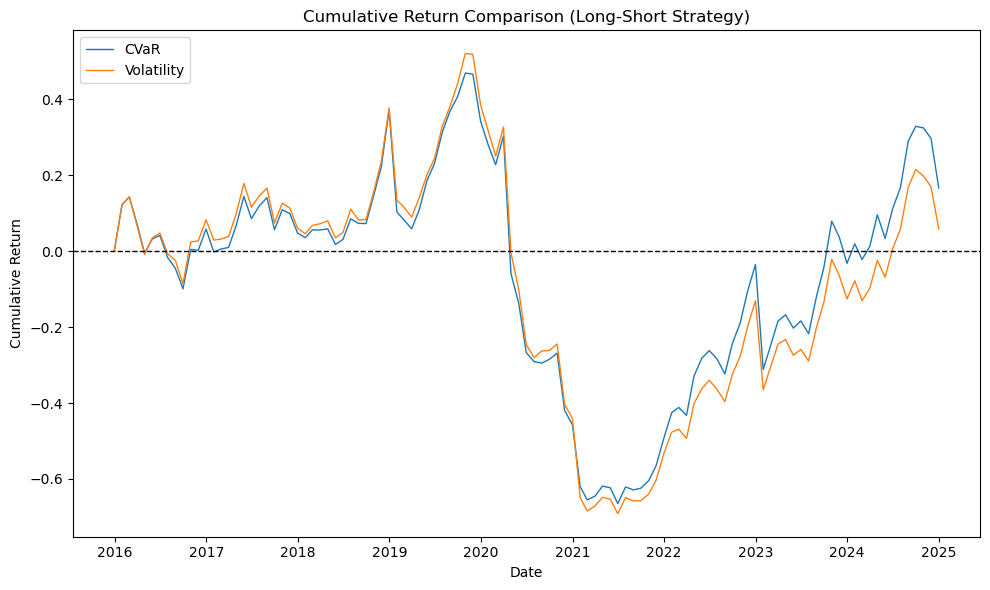

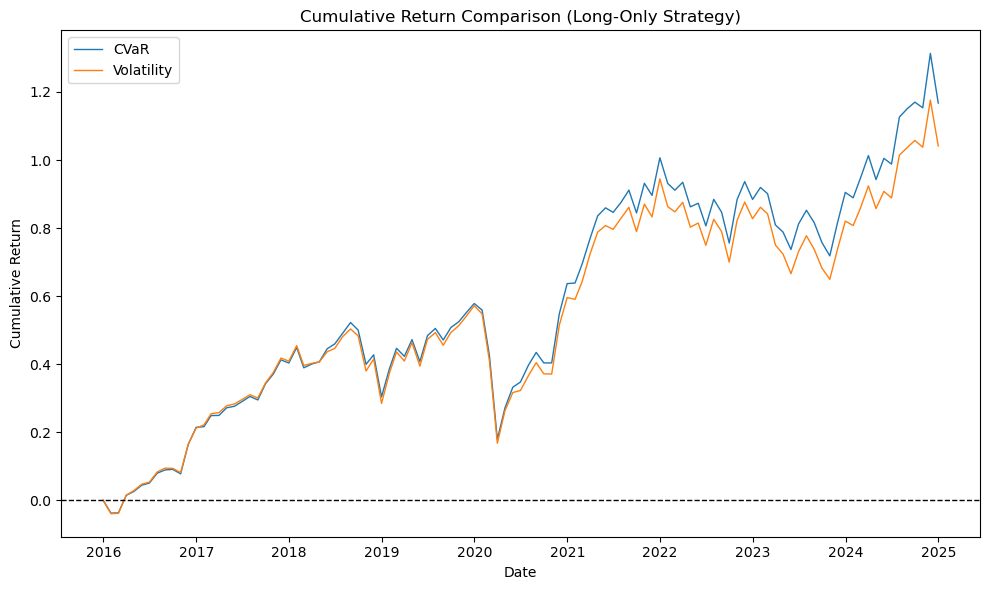

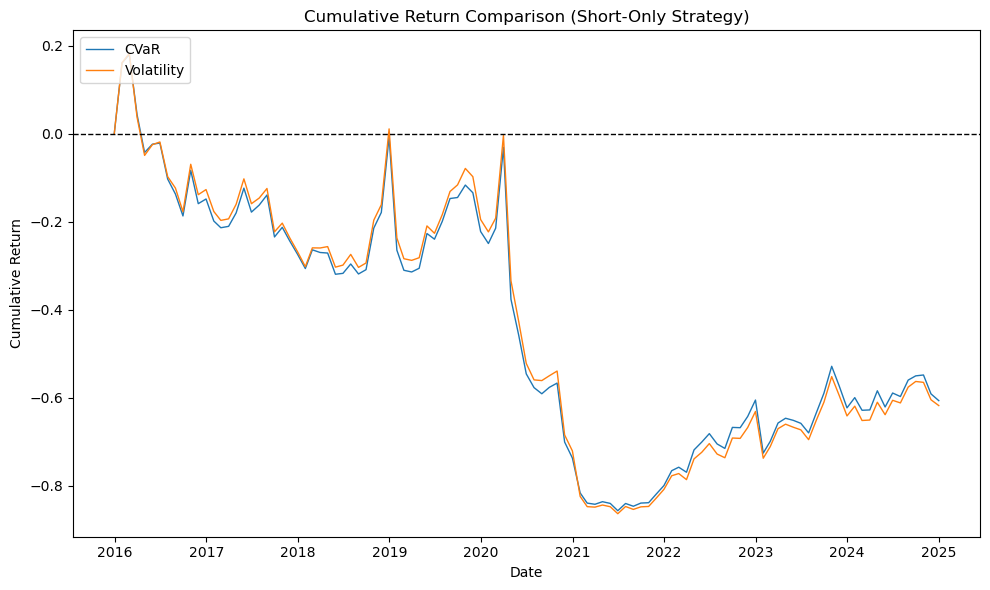

In [39]:
for strategy in ['long_short', 'long_only', 'short_only']:
    # Calculte CVaR cumulative returns
    cvar_rets = port_rets_dict[('tail_score', strategy)]
    cvar_cum_rets = (1 + cvar_rets).cumprod() - 1
    cvar_cum_rets = pd.concat([pd.Series([0], index=[cvar_rets.index[0] - pd.DateOffset(months=1)]), cvar_cum_rets])

    # Calculate benchmark cumulative returns
    vol_rets = port_rets_dict[('vol', strategy)]
    vol_cum_rets = (1 + vol_rets).cumprod() - 1
    vol_cum_rets = pd.concat([pd.Series([0], index=[vol_rets.index[0] - pd.DateOffset(months=1)]), vol_cum_rets])

    # Compare both cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cvar_cum_rets.index, cvar_cum_rets, label='CVaR', linewidth=1)
    plt.plot(vol_cum_rets.index, vol_cum_rets, label='Volatility', linewidth=1)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Return Comparison ({strategy.replace("_", "-").title()} Strategy)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

### 6. Regression Analysis

#### 6.1. Fama-MacBeth Regression

In [41]:
def fmb_regression(fmb_data, cvar_panel, vol_panel):
    # Combine both factor panels
    factor_panel = pd.merge(
        cvar_panel[['PERMNO', 'date', 'tail_score']], 
        vol_panel[['PERMNO', 'date', 'vol']], 
        on=['PERMNO', 'date'], 
        how='inner'
    )

    # Single merge with fmb_data
    merged_data = pd.merge(fmb_data, factor_panel, on=['PERMNO', 'date'], how='inner')

    # Capitalize factor columns
    merged_data.rename(columns={
        'tail_score': 'TAIL_SCORE',
        'vol': 'VOL'
    }, inplace=True)

    # Drop rows with NaN values
    merged_data.dropna(inplace=True)

    # Define all factors
    factors = ['LOG_MCAP', 'BM', 'OP', 'MOM', 'TAIL_SCORE', 'VOL']

    # Standardize each factor
    for f in factors:
        merged_data[f'{f}_STD'] = merged_data.groupby('date')[f].transform(
            lambda x: (x - x.mean()) / x.std()
        )

    # Run cross-sectional regression
    def cs_regression(group):
        y = group['RET_RF_T1']
        X = group[[f'{f}_STD' for f in factors]]
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()
        return pd.Series(model.params, index=model.params.index)
    
    # Get coefficients for each month
    monthly_coefs = merged_data.groupby('date').apply(cs_regression).reset_index()

    # Average factor coefficients across time
    avg_coefs = monthly_coefs[[f'{f}_STD' for f in factors] + ['const']].mean()

    # Calculate t-stat for each factor
    n_months = len(monthly_coefs)
    std_coefs = monthly_coefs[[f'{f}_STD' for f in factors] + ['const']].std()
    t_stats = avg_coefs / (std_coefs / np.sqrt(n_months))

    # Print summary
    results = pd.DataFrame({ 
        'Estimate': avg_coefs, 
        't-stat': t_stats 
    })
    results.index = results.index.str.replace('_STD', '')
    results.rename(index={'const': 'CONST'}, inplace=True)
    print(results)

In [42]:
print('='*30)
print('FAMA-MACBETH REGRESSION')
print('='*30)
fmb_regression(fmb_data, cvar_panel, vol_panel)

FAMA-MACBETH REGRESSION
            Estimate    t-stat
LOG_MCAP   -0.001161 -0.965330
BM          0.001464  1.284111
OP          0.000063  0.270578
MOM         0.001216  1.023362
TAIL_SCORE  0.004273  1.172400
VOL        -0.002268 -0.989481
CONST       0.011146  1.951117


#### 6.2. Fama-French Regression

In [43]:
def ff_regression(ff_data, port_rets):
    # Merge data and calculate excess returns
    merged_data = pd.merge(ff_data, port_rets.reset_index(), on='date', how='inner')
    merged_data['monthly_excess_ret'] = merged_data['monthly_ret'] - merged_data['RF']

    # Define dependent and independent variables
    y = merged_data['monthly_excess_ret']
    X = merged_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'MOM']]
    X = sm.add_constant(X)

    # Run OLS regression and print summary
    model = sm.OLS(y, X).fit()
    print(model.summary())    

In [46]:
for strategy in ['long_short', 'long_only', 'short_only']:
    for factor in ['tail_score', 'vol']:
        port_rets = port_rets_dict[(factor, strategy)]
        print('\n' + '='*78)
        print(f'FAMA-FRENCH 5-FACTOR REGRESSION: {"TAIL SCORE" if factor == "tail_score" else "VOLATILITY"} {strategy.upper().replace("_", "-")} STRATEGY')
        print('='*78)
        ff_regression(ff_data, port_rets)


FAMA-FRENCH 5-FACTOR REGRESSION: TAIL SCORE LONG-SHORT STRATEGY
                            OLS Regression Results                            
Dep. Variable:     monthly_excess_ret   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     32.44
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.16e-19
Time:                        21:54:30   Log-Likelihood:                 163.50
No. Observations:                 108   AIC:                            -315.0
Df Residuals:                     102   BIC:                            -298.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

### 7. Beta Neutralization

In [47]:
def rolling_beta(panel, ff_data, window=12):
    # Merge panel with market returns
    merged_panel = pd.merge(cvar_panel_ls, ff_data[['date', 'Mkt']], on='date', how='inner')

    # Sort by PERMNO and date
    merged_panel = merged_panel.sort_values(by=['PERMNO', 'date']).reset_index(drop=True)

    # Function to compute beta using rolling 12-month window
    def compute_beta(group):
        cov = group['monthly_ret'].rolling(window).cov(group['Mkt'])
        var = group['Mkt'].rolling(window).var()
        return cov / var
    
    # Calculate rolling beta for each stock
    merged_panel['beta'] = merged_panel.groupby('PERMNO').apply(compute_beta).reset_index(level=0, drop=True)

    # Drop rows with NaN values for beta
    merged_panel = merged_panel.dropna(subset=['beta'])

    return merged_panel

In [48]:
# Beta neutralize CVaR factor
cvar_panel_ls_beta = rolling_beta(cvar_panel_ls, ff_data)
cvar_ls_beta_rets = calculate_port_returns(cvar_panel_ls_beta, strategy='long_short', beta_hedge=True)

# Beta neutralize volatility factor
vol_panel_ls_beta = rolling_beta(vol_panel_ls, ff_data)
vol_ls_beta_rets = calculate_port_returns(vol_panel_ls_beta, strategy='long_short', beta_hedge=True)

In [49]:
# Compare performance sumamry
for factor in ['tail_score', 'vol']:
    port_rets = cvar_ls_beta_rets if factor == 'tail_score' else vol_ls_beta_rets
    summarize_performance(port_rets, factor=factor, strategy='long_short')

Performance Summary:
Factor:                tail_score
Strategy:              long_short
Sample period:         2016-12 to 2024-12
Number of months:      97
Mean monthly return:   1.82%
Annualized return:     21.81%
Monthly stdev:         8.62%
Annualized stdev:      29.85%
T-statistic:           2.08
Sharpe ratio:          0.73
Cumulative return:     294.93%
Max drawdown:          -58.66%

Performance Summary:
Factor:                vol
Strategy:              long_short
Sample period:         2016-12 to 2024-12
Number of months:      97
Mean monthly return:   1.82%
Annualized return:     21.81%
Monthly stdev:         8.62%
Annualized stdev:      29.85%
T-statistic:           2.08
Sharpe ratio:          0.73
Cumulative return:     294.93%
Max drawdown:          -58.66%



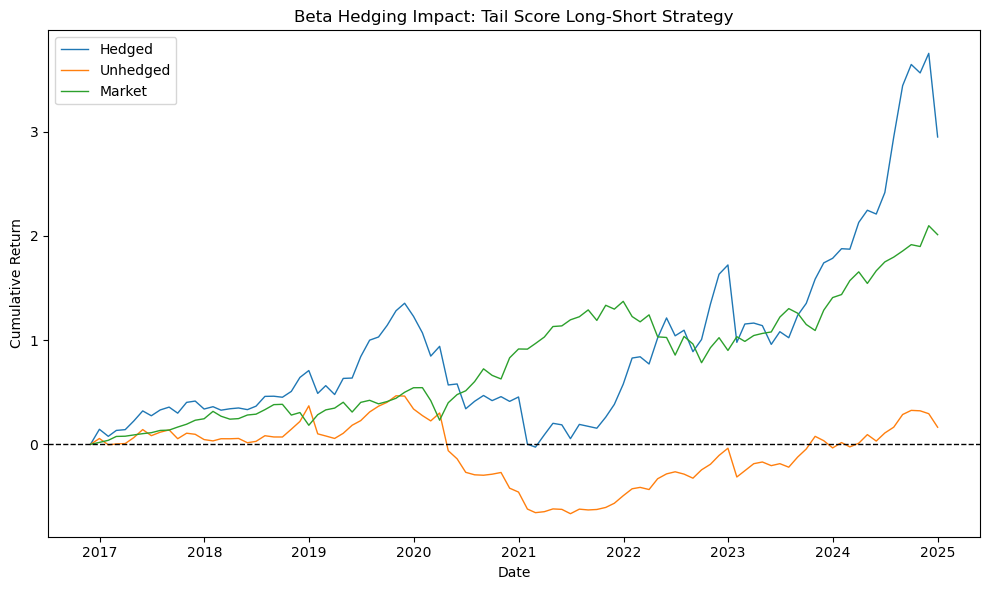

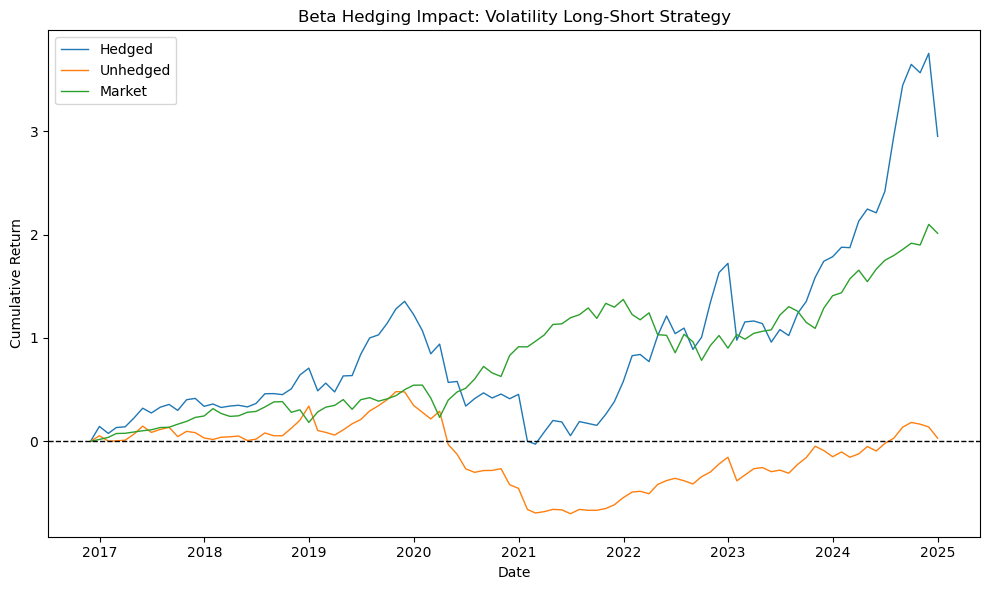

In [50]:
for factor in ['tail_score', 'vol']:
    # Get beta hedged portfolio returns
    hedged_rets = cvar_ls_beta_rets if factor == 'tail_score' else vol_ls_beta_rets
    hedged_cum_rets = (1 + hedged_rets).cumprod() - 1
    hedged_cum_rets = pd.concat([pd.Series([0], index=[hedged_rets.index[0] - pd.DateOffset(months=1)]), hedged_cum_rets])

    # Define start and end dates
    start_date, end_date = hedged_rets.index[0], hedged_rets.index[-1]

    # Get unhedged portfolio returns
    unhedged_rets = port_rets_dict[(factor, 'long_short')].loc[start_date:end_date]
    unhedged_cum_rets = (1 + unhedged_rets).cumprod() - 1
    unhedged_cum_rets = pd.concat([pd.Series([0], index=[unhedged_rets.index[0] - pd.DateOffset(months=1)]), unhedged_cum_rets])

    # Get market returns
    mkt_rets = ff_data[(ff_data['date'] >= start_date) & (ff_data['date'] <= end_date)].set_index('date')['Mkt']
    mkt_cum_rets = (1 + mkt_rets).cumprod() - 1
    mkt_cum_rets = pd.concat([pd.Series([0], index=[mkt_rets.index[0] - pd.DateOffset(months=1)]), mkt_cum_rets])

    # Compare all cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(hedged_cum_rets.index, hedged_cum_rets, label='Hedged', linewidth=1)
    plt.plot(unhedged_cum_rets.index, unhedged_cum_rets, label='Unhedged', linewidth=1)
    plt.plot(mkt_cum_rets.index, mkt_cum_rets, label='Market', linewidth=1)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Beta Hedging Impact: {"Tail Score" if factor == "tail_score" else "Volatility"} Long-Short Strategy')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

### 8. Robustness & Bias Control

#### 8.1. Helper Functions

In [51]:
def create_cvar_panel(df_daily, df_monthly, window=252, alpha=0.05):
    # Make a copy of dataframe
    cvar_daily = df_daily.copy()

    # Apply rolling CVaR per stock (PERMNO)
    cvar_daily['cvar'] = (
        cvar_daily.groupby('PERMNO')['daily_ret']
                  .rolling(window=window, min_periods=window)
                  .apply(rolling_cvar, kwargs={'alpha': alpha}, raw=True)
                  .reset_index(level=0, drop=True)
    )

    # TailScore is defined as -CVaR
    # Higher TailScore ⇒ more severe downside tail (worse tails)
    cvar_daily['tail_score'] = -cvar_daily['cvar']

    # For each stock and month, keep only the last trading day of that month
    # This gives us the month-end TailScore used to form next month's portfolio
    cvar_monthly = (
        cvar_daily.sort_values(['PERMNO', 'date'])
                  .groupby(['PERMNO', 'month'])
                  .tail(1)
                  .copy()
    )

    # Drop month-end rows where TailScore is still NaN (this happens for the first 252 trading days of each stock's history)
    cvar_monthly = cvar_monthly.dropna(subset=['tail_score'])

    # Offset date to end of month
    cvar_monthly['date'] = cvar_monthly['date'] + pd.offsets.MonthEnd(0)

    # Merge month-end TailScore snapshot with next month's return
    # Each row now represents: stock i, month t, TailScore_t, and return_{t+1}
    cvar_panel = cvar_monthly.merge(
        df_monthly[['PERMNO', 'month', 'monthly_ret', 'monthly_ret_next']],
        on=['PERMNO', 'month'],
        how='left'
    )

    # Drop rows where we don't observe the next month's return
    cvar_panel = cvar_panel.dropna(subset=['monthly_ret_next'])

    return cvar_panel

In [52]:
def calculate_turnover(panel):
    # Sort by PERMNO and month
    panel = panel.sort_values(['PERMNO', 'month']).reset_index(drop=True)

    # Create lagged flag for each stock
    panel['prev_flag'] = panel.groupby('PERMNO')['ls_flag'].shift(1)

    turnover_data = []

    for month in panel['month'].unique():
        # Get current month's portfolios
        month_data = panel[panel['month'] == month]
        current_long = set(month_data[month_data['ls_flag'] == 1]['PERMNO'])
        current_short = set(month_data[month_data['ls_flag'] == -1]['PERMNO'])

        # Get previous month's portfolios
        prev_month_data = panel[panel['month'] == month - 1]
        prev_long = set(prev_month_data[prev_month_data['ls_flag'] == 1]['PERMNO'])
        prev_short = set(prev_month_data[prev_month_data['ls_flag'] == -1]['PERMNO'])

        # Calculate turnover if previous month exists
        if len(prev_long) > 0 and len(prev_short) > 0:
            # Turnover = (new stocks) / (previous portfolio size)
            long_turnover = len(current_long - prev_long) / len(prev_long)
            short_turnover = len(current_short - prev_short) / len(prev_short)
            total_turnover = (long_turnover + short_turnover) / 2

            turnover_data.append({
                'month': month,
                'long_turnover': long_turnover,
                'short_turnover': short_turnover,
                'total_turnover': total_turnover
            })

    turnover_df = pd.DataFrame(turnover_data)

    return turnover_df

In [53]:
def apply_transaction_costs(port_rets, turnover_df, tc_bps=50):
    # Convert month to date format for merging
    turnover_df['date'] = pd.to_datetime(turnover_df['month'].astype(str)) + pd.offsets.MonthEnd(0)
    turnover_df = turnover_df.set_index('date')

    # Merge portfolio returns with turnover data
    combined = pd.merge(
        port_rets.reset_index(),
        turnover_df[['total_turnover']],
        left_on='date',
        right_index=True,
        how='inner'
    )

    # Calculate transaction cost (turnover × cost in decimal)
    combined['transaction_cost'] = combined['total_turnover'] * (tc_bps / 10000)
    
    # Net return = gross return - transaction cost
    combined['net_ret'] = combined['monthly_ret'] - combined['transaction_cost']

    return combined.set_index('date')['net_ret']

In [54]:
def apply_short_costs(port_rets, turnover_df, sc_bps=50):
    # Convert month to date format for merging
    turnover_df['date'] = pd.to_datetime(turnover_df['month'].astype(str)) + pd.offsets.MonthEnd(0)
    turnover_df = turnover_df.set_index('date')

    # Merge portfolio returns with turnover data
    combined = pd.merge(
        port_rets.reset_index(),
        turnover_df[['short_turnover']],
        left_on='date',
        right_index=True,
        how='inner'
    )

    # Calculate short sale cost (cost in decimal / 12)
    combined['short_cost'] = (sc_bps / 10000) / 12

    # Net return = gross return - short sale cost
    combined['net_ret'] = combined['monthly_ret'] - combined['short_cost']

    return combined.set_index('date')['net_ret']

#### 8.2. Lookback Window Sensitivity

In [55]:
windows = [63, 126, 252]
alpha = 0.05
q = 0.2

window_results = {}

for window in windows:
    # Create CVaR panel for given window
    cvar_panel = create_cvar_panel(df_daily, df_monthly, window=window, alpha=alpha)

    # Assign flags to long-short strategy
    cvar_panel = cvar_panel.groupby('month').apply(assign_ls_flags, factor='tail_score', q=q, strategy='long_short').reset_index(drop=True)

    # Compute equal-weight portfolio returns
    cvar_rets = calculate_port_returns(cvar_panel, strategy='long_short')

    # Store portfolio returns
    window_results[window] = cvar_rets

In [56]:
# Define start and end dates for alignment
start_date = max([port_rets.index[0] for port_rets in window_results.values()])
end_date = min([port_rets.index[-1] for port_rets in window_results.values()])

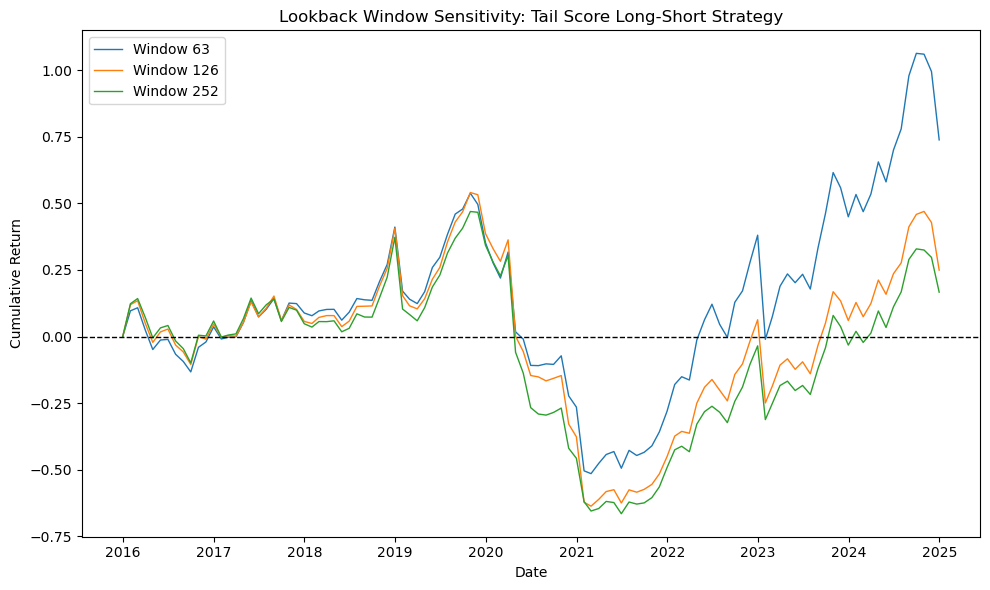

In [57]:
plt.figure(figsize=(10, 6))

for window, port_rets in window_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]
    port_cum_rets = (1 + port_rets_aligned).cumprod() - 1
    port_cum_rets = pd.concat([pd.Series([0], index=[port_rets_aligned.index[0] - pd.DateOffset(months=1)]), port_cum_rets])
    plt.plot(port_cum_rets.index, port_cum_rets, label=f'Window {window}', linewidth=1)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Lookback Window Sensitivity: Tail Score Long-Short Strategy')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [58]:
window_summary = pd.DataFrame()

for window, port_rets in window_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]

    ann_mean_ret = port_rets_aligned.mean() * 12
    ann_std_ret = port_rets_aligned.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    window_summary[f'Window {window}'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe,
    })

print('='*70)
print('LOOKBACK WINDOW SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(window_summary.T)

LOOKBACK WINDOW SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY
            Annualized Return  Annualized Volatility  Sharpe Ratio
Window 63            0.104958               0.284942      0.368348
Window 126           0.076156               0.304788      0.249865
Window 252           0.064880               0.298940      0.217033


#### 8.3. Tail Threshold Sensitivity

In [59]:
window = 252
alphas = [0.01, 0.05, 0.1] 
q = 0.2

alpha_results = {}

for alpha in alphas:
    # Create CVaR panel for given window
    cvar_panel = create_cvar_panel(df_daily, df_monthly, window=window, alpha=alpha)

    # Assign flags to long-short strategy
    cvar_panel = cvar_panel.groupby('month').apply(assign_ls_flags, factor='tail_score', q=q, strategy='long_short').reset_index(drop=True)

    # Compute equal-weight portfolio returns
    cvar_rets = calculate_port_returns(cvar_panel, strategy='long_short')

    # Store portfolio returns
    alpha_results[alpha] = cvar_rets

In [60]:
# Define start and end dates for alignment
start_date = max([port_rets.index[0] for port_rets in alpha_results.values()])
end_date = min([port_rets.index[-1] for port_rets in alpha_results.values()])

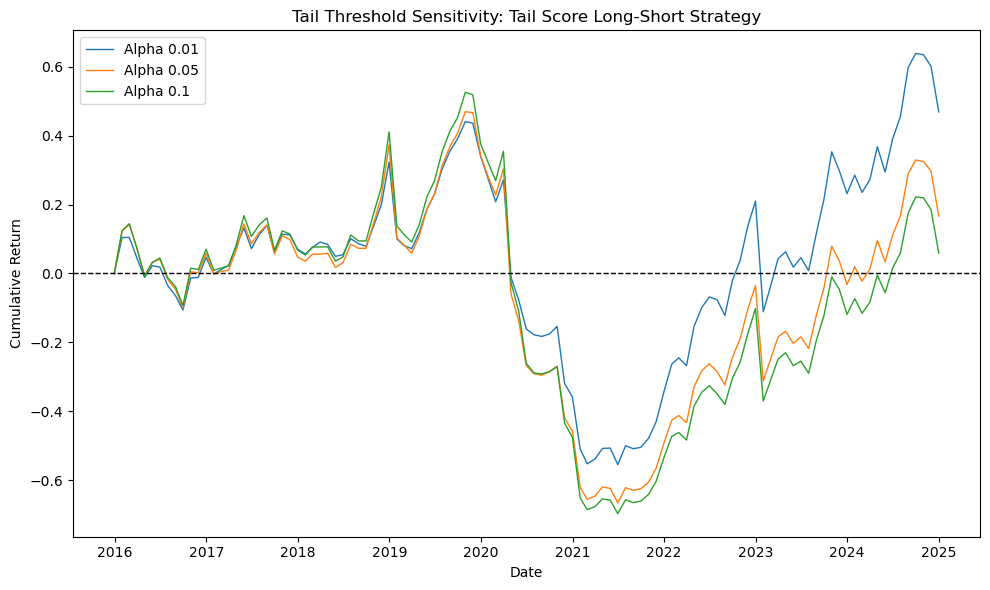

In [61]:
plt.figure(figsize=(10, 6))

for alpha, port_rets in alpha_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]
    port_cum_rets = (1 + port_rets_aligned).cumprod() - 1
    port_cum_rets = pd.concat([pd.Series([0], index=[port_rets_aligned.index[0] - pd.DateOffset(months=1)]), port_cum_rets])
    plt.plot(port_cum_rets.index, port_cum_rets, label=f'Alpha {alpha}', linewidth=1)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Tail Threshold Sensitivity: Tail Score Long-Short Strategy')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
alpha_summary = pd.DataFrame()

for alpha, port_rets in alpha_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]

    ann_mean_ret = port_rets_aligned.mean() * 12
    ann_std_ret = port_rets_aligned.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    alpha_summary[f'Alpha {alpha}'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe,
    })

print('='*70)
print('TAIL THRESHOLD SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(alpha_summary.T)

TAIL THRESHOLD SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY
            Annualized Return  Annualized Volatility  Sharpe Ratio
Alpha 0.01           0.078256               0.260220      0.300729
Alpha 0.05           0.064880               0.298940      0.217033
Alpha 0.1            0.059175               0.312846      0.189150


#### 8.4. Portfolio Cutoff Sensitivity

In [63]:
window = 252
alpha = 0.05
quantiles = [0.1, 0.2, 0.3]

q_results = {}

for q in quantiles:
    # Create CVaR panel for given window
    cvar_panel = create_cvar_panel(df_daily, df_monthly, window=window, alpha=alpha)

    # Assign flags to long-short strategy
    cvar_panel = cvar_panel.groupby('month').apply(assign_ls_flags, factor='tail_score', q=q, strategy='long_short').reset_index(drop=True)

    # Compute equal-weight portfolio returns
    cvar_rets = calculate_port_returns(cvar_panel, strategy='long_short')

    # Store portfolio returns
    q_results[q] = cvar_rets

In [64]:
# Define start and end dates for alignment
start_date = max([port_rets.index[0] for port_rets in alpha_results.values()])
end_date = min([port_rets.index[-1] for port_rets in alpha_results.values()])

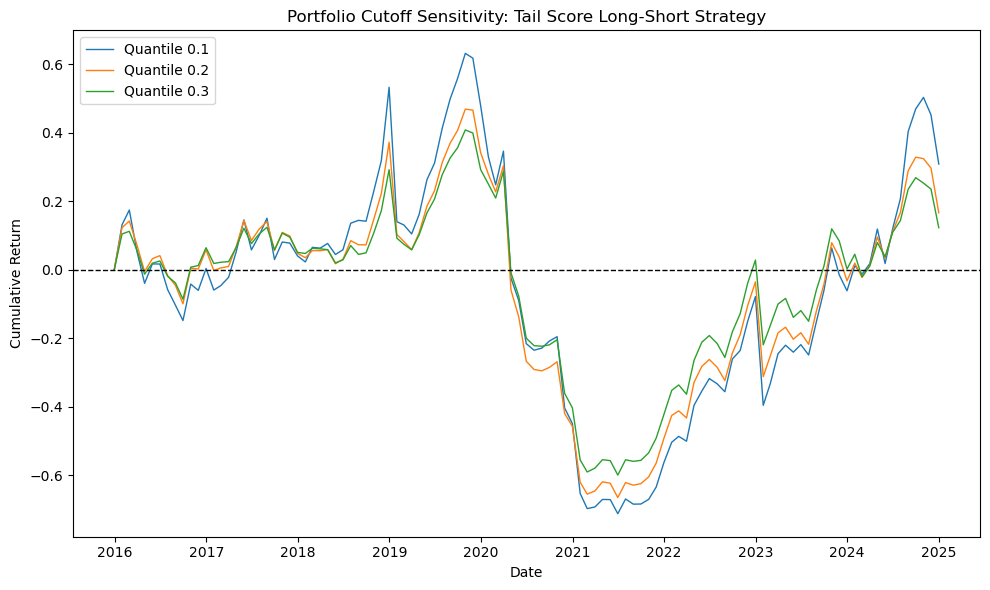

In [65]:
plt.figure(figsize=(10, 6))

for q, port_rets in q_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]
    port_cum_rets = (1 + port_rets_aligned).cumprod() - 1
    port_cum_rets = pd.concat([pd.Series([0], index=[port_rets_aligned.index[0] - pd.DateOffset(months=1)]), port_cum_rets])
    plt.plot(port_cum_rets.index, port_cum_rets, label=f'Quantile {q}', linewidth=1)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Portfolio Cutoff Sensitivity: Tail Score Long-Short Strategy')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [66]:
q_summary = pd.DataFrame()

for q, port_rets in q_results.items():
    port_rets_aligned = port_rets.loc[start_date:end_date]

    ann_mean_ret = port_rets_aligned.mean() * 12
    ann_std_ret = port_rets_aligned.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    q_summary[f'Quantile {q}'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe,
    })

print('='*70)
print('PORTFOLIO CUTOFF SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(q_summary.T)

PORTFOLIO CUTOFF SENSITIVITY: TAIL SCORE LONG-SHORT STRATEGY
              Annualized Return  Annualized Volatility  Sharpe Ratio
Quantile 0.1           0.097189               0.351076      0.276832
Quantile 0.2           0.064880               0.298940      0.217033
Quantile 0.3           0.047785               0.257651      0.185463


#### 8.5. Portfolio Turnover Analysis

In [69]:
cvar_turnover_ls = calculate_turnover(cvar_panel_ls)
vol_turnover_ls = calculate_turnover(vol_panel_ls)

print('='*70)
print('MONTHLY TURNOVER STATISTICS: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(f"Average Total Turnover: {cvar_turnover_ls['total_turnover'].mean():.2%}")
print(f"Average Long Leg Turnover: {cvar_turnover_ls['long_turnover'].mean():.2%}")
print(f"Average Short Leg Turnover: {cvar_turnover_ls['short_turnover'].mean():.2%}")

print('\n' + '='*70)
print('MONTHLY TURNOVER STATISTICS: VOLATILITY LONG-SHORT STRATEGY')
print('='*70)
print(f"Average Total Turnover: {vol_turnover_ls['total_turnover'].mean():.2%}")
print(f"Average Long Leg Turnover: {vol_turnover_ls['long_turnover'].mean():.2%}")
print(f"Average Short Leg Turnover: {vol_turnover_ls['short_turnover'].mean():.2%}")

MONTHLY TURNOVER STATISTICS: TAIL SCORE LONG-SHORT STRATEGY
Average Total Turnover: 7.73%
Average Long Leg Turnover: 8.04%
Average Short Leg Turnover: 7.42%

MONTHLY TURNOVER STATISTICS: VOLATILITY LONG-SHORT STRATEGY
Average Total Turnover: 6.20%
Average Long Leg Turnover: 6.00%
Average Short Leg Turnover: 6.39%


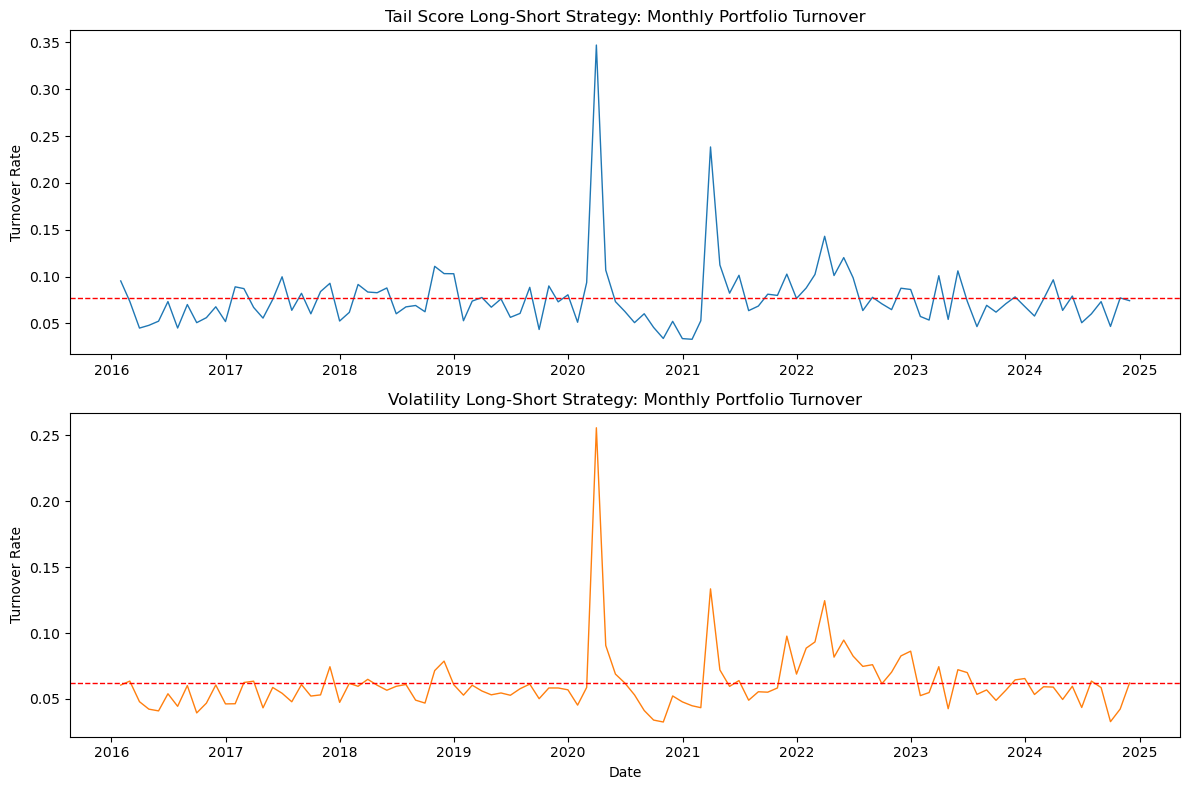

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

cvar_turnover_ls['date'] = pd.to_datetime(cvar_turnover_ls['month'].astype(str)) + pd.offsets.MonthEnd(0)
axes[0].plot(cvar_turnover_ls['date'], cvar_turnover_ls['total_turnover'], linewidth=1, color='tab:blue')
axes[0].axhline(cvar_turnover_ls['total_turnover'].mean(), color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Turnover Rate')
axes[0].set_title('Tail Score Long-Short Strategy: Monthly Portfolio Turnover')

vol_turnover_ls['date'] = pd.to_datetime(vol_turnover_ls['month'].astype(str)) + pd.offsets.MonthEnd(0)
axes[1].plot(vol_turnover_ls['date'], vol_turnover_ls['total_turnover'], linewidth=1, color='tab:orange')
axes[1].axhline(vol_turnover_ls['total_turnover'].mean(), color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Turnover Rate')
axes[1].set_title('Volatility Long-Short Strategy: Monthly Portfolio Turnover')

plt.tight_layout()
plt.show()

#### 8.6. Transaction Cost Adjustment

In [70]:
tc_scenarios = [10, 25, 50, 100]

cvar_tc_results = {}
for tc in tc_scenarios:
    cvar_tc_results[tc] = apply_transaction_costs(
        port_rets_dict[('tail_score', 'long_short')],
        cvar_turnover_ls,
        tc_bps=tc
    )

vol_tc_results = {}
for tc in tc_scenarios:
    vol_tc_results[tc] = apply_transaction_costs(
        port_rets_dict[('vol', 'long_short')],
        vol_turnover_ls,
        tc_bps=tc
    )

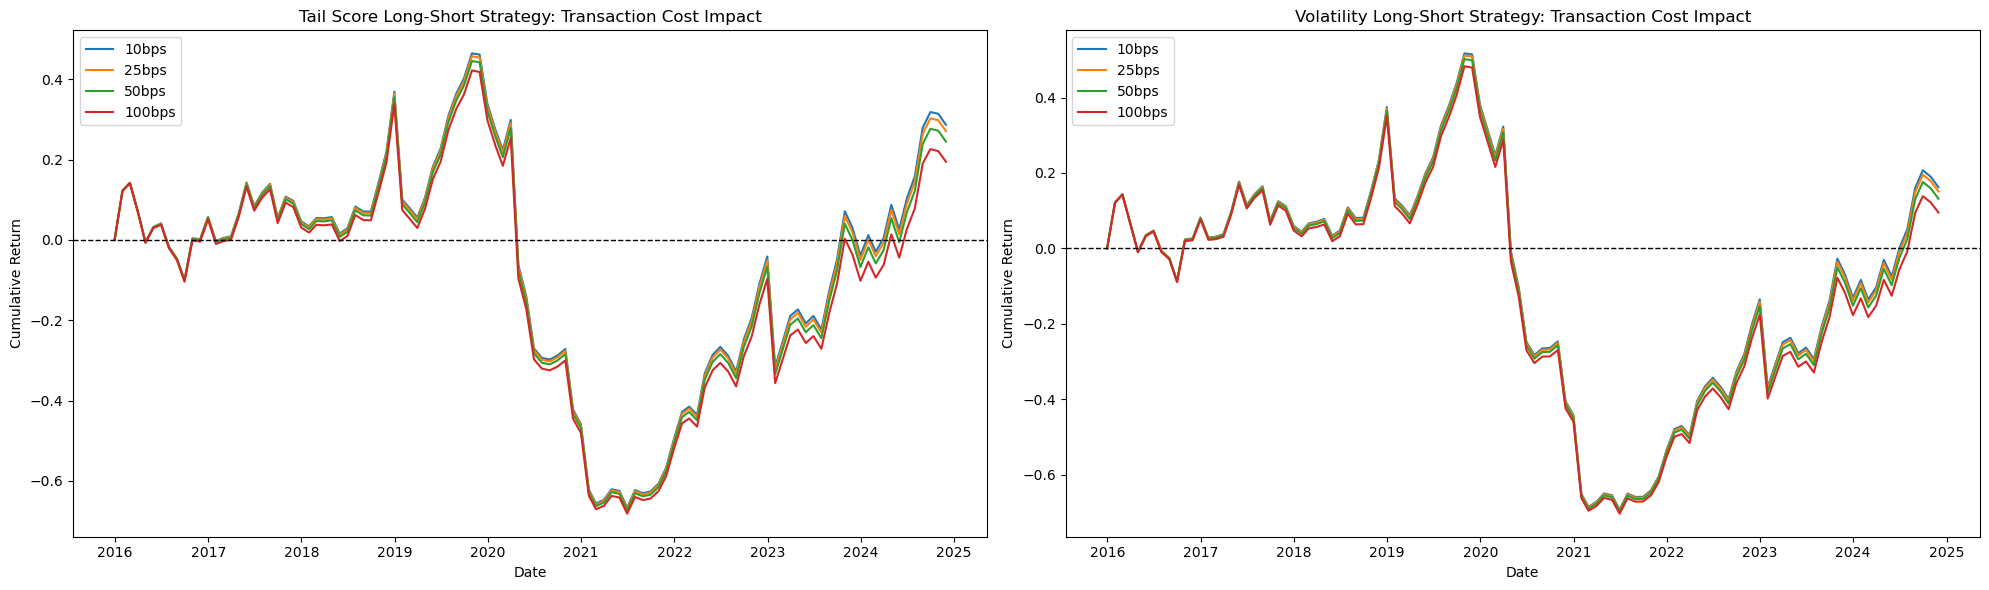

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for tc, rets in cvar_tc_results.items():
    cum_rets = (1 + rets).cumprod() - 1
    cum_rets = pd.concat([
        pd.Series([0], index=[rets.index[0] - pd.DateOffset(months=1)]),
        cum_rets
    ])
    axes[0].plot(cum_rets.index, cum_rets, label=f'{tc}bps', linewidth=1.5)

axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Tail Score Long-Short Strategy: Transaction Cost Impact')
axes[0].legend(loc='upper left')

for tc, rets in vol_tc_results.items():
    cum_rets = (1 + rets).cumprod() - 1
    cum_rets = pd.concat([
        pd.Series([0], index=[rets.index[0] - pd.DateOffset(months=1)]),
        cum_rets
    ])
    axes[1].plot(cum_rets.index, cum_rets, label=f'{tc}bps', linewidth=1.5)

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return')
axes[1].set_title('Volatility Long-Short Strategy: Transaction Cost Impact')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [72]:
cvar_tc_summary = pd.DataFrame()
for tc, port_rets in cvar_tc_results.items():
    ann_mean_ret = port_rets.mean() * 12
    ann_std_ret = port_rets.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    cvar_tc_summary[f'{tc}bps'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe
    })

vol_tc_summary = pd.DataFrame()
for tc, port_rets in vol_tc_results.items():
    ann_mean_ret = port_rets.mean() * 12
    ann_std_ret = port_rets.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    vol_tc_summary[f'{tc}bps'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe
    })

print('='*70)
print('TRANSACTION COST IMPACT: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(cvar_tc_summary.T)

print('\n' + '='*70)
print('TRANSACTION COST IMPACT: VOLATILITY LONG-SHORT STRATEGY')
print('='*70)
print(vol_tc_summary.T)

TRANSACTION COST IMPACT: TAIL SCORE LONG-SHORT STRATEGY
        Annualized Return  Annualized Volatility  Sharpe Ratio
10bps            0.075839               0.298180      0.254341
25bps            0.074448               0.298147      0.249701
50bps            0.072128               0.298092      0.241966
100bps           0.067490               0.297984      0.226487

TRANSACTION COST IMPACT: VOLATILITY LONG-SHORT STRATEGY
        Annualized Return  Annualized Volatility  Sharpe Ratio
10bps            0.067566               0.305758      0.220979
25bps            0.066451               0.305740      0.217344
50bps            0.064592               0.305710      0.211285
100bps           0.060875               0.305652      0.199163


#### 8.7. Short Sale Cost Adjustment

In [73]:
sc_scenarios = [25, 50, 100, 200]

cvar_sc_results = {}
for sc in sc_scenarios:
    cvar_sc_results[sc] = apply_short_costs(
        port_rets_dict[('tail_score', 'long_short')],
        cvar_turnover_ls,
        sc_bps=sc
    )

vol_sc_results = {}
for sc in sc_scenarios:
    vol_sc_results[sc] = apply_short_costs(
        port_rets_dict[('vol', 'long_short')],
        vol_turnover_ls,
        sc_bps=sc
    )

In [74]:
cvar_sc_summary = pd.DataFrame()
for sc, port_rets in cvar_sc_results.items():
    ann_mean_ret = port_rets.mean() * 12
    ann_std_ret = port_rets.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    cvar_sc_summary[f'{sc}bps'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe
    })

vol_sc_summary = pd.DataFrame()
for sc, port_rets in vol_sc_results.items():
    ann_mean_ret = port_rets.mean() * 12
    ann_std_ret = port_rets.std() * np.sqrt(12)
    ann_sharpe = ann_mean_ret / ann_std_ret if ann_std_ret > 0 else np.nan

    vol_sc_summary[f'{sc}bps'] = pd.Series({
        'Annualized Return': ann_mean_ret,
        'Annualized Volatility': ann_std_ret,
        'Sharpe Ratio': ann_sharpe
    })

print('='*70)
print('SHORT SALE COST IMPACT: TAIL SCORE LONG-SHORT STRATEGY')
print('='*70)
print(cvar_sc_summary.T)

print('\n' + '='*70)
print('SHORT SALE COST IMPACT: VOLATILITY LONG-SHORT STRATEGY')
print('='*70)
print(vol_sc_summary.T)

SHORT SALE COST IMPACT: TAIL SCORE LONG-SHORT STRATEGY
        Annualized Return  Annualized Volatility  Sharpe Ratio
25bps            0.074267               0.298202      0.249049
50bps            0.071767               0.298202      0.240666
100bps           0.066767               0.298202      0.223899
200bps           0.056767               0.298202      0.190364

SHORT SALE COST IMPACT: VOLATILITY LONG-SHORT STRATEGY
        Annualized Return  Annualized Volatility  Sharpe Ratio
25bps             0.06581                0.30577      0.215226
50bps             0.06331                0.30577      0.207050
100bps            0.05831                0.30577      0.190698
200bps            0.04831                0.30577      0.157993


### 9. Regime Analysis

#### 9.1. Regime 1 (2016-2019)

In [75]:
start_date = '2016-01-31'
end_date = '2019-12-31'

# Compare performance across different strategies and factors
for strategy in ['long_short', 'long_only', 'short_only']:
    for factor in ['tail_score', 'vol']:
        port_rets = port_rets_dict[(factor, strategy)]
        port_rets = port_rets.loc[start_date:end_date]
        summarize_performance(port_rets, factor=factor, strategy=strategy)

Performance Summary:
Factor:                tail_score
Strategy:              long_short
Sample period:         2016-01 to 2019-12
Number of months:      48
Mean monthly return:   0.79%
Annualized return:     9.50%
Monthly stdev:         5.94%
Annualized stdev:      20.57%
T-statistic:           0.92
Sharpe ratio:          0.46
Cumulative return:     34.21%
Max drawdown:          -22.85%

Performance Summary:
Factor:                vol
Strategy:              long_short
Sample period:         2016-01 to 2019-12
Number of months:      48
Mean monthly return:   0.85%
Annualized return:     10.19%
Monthly stdev:         5.82%
Annualized stdev:      20.17%
T-statistic:           1.01
Sharpe ratio:          0.51
Cumulative return:     38.48%
Max drawdown:          -20.89%

Performance Summary:
Factor:                tail_score
Strategy:              long_only
Sample period:         2016-01 to 2019-12
Number of months:      48
Mean monthly return:   1.00%
Annualized return:     12.03%
Monthly

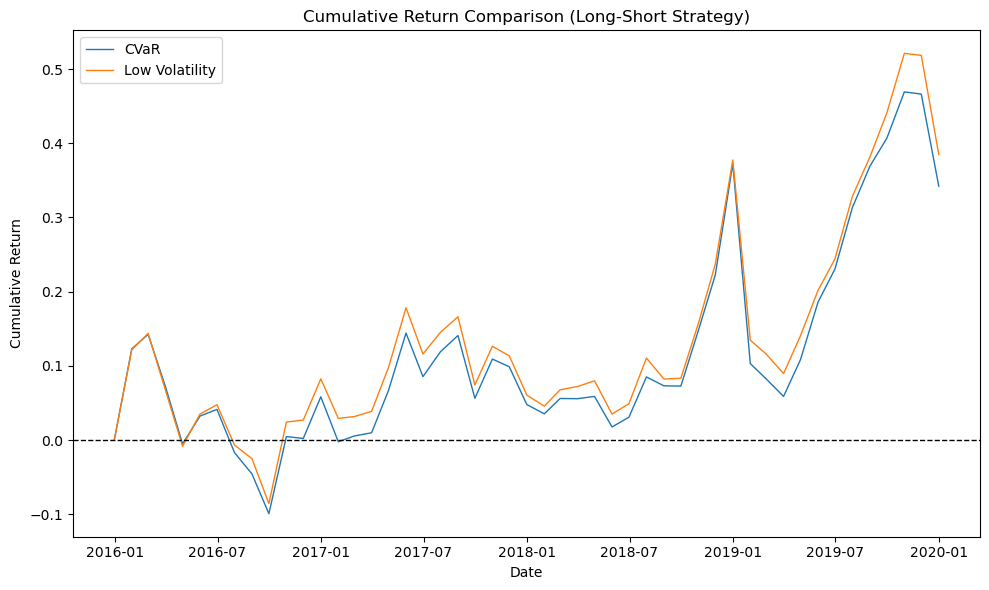

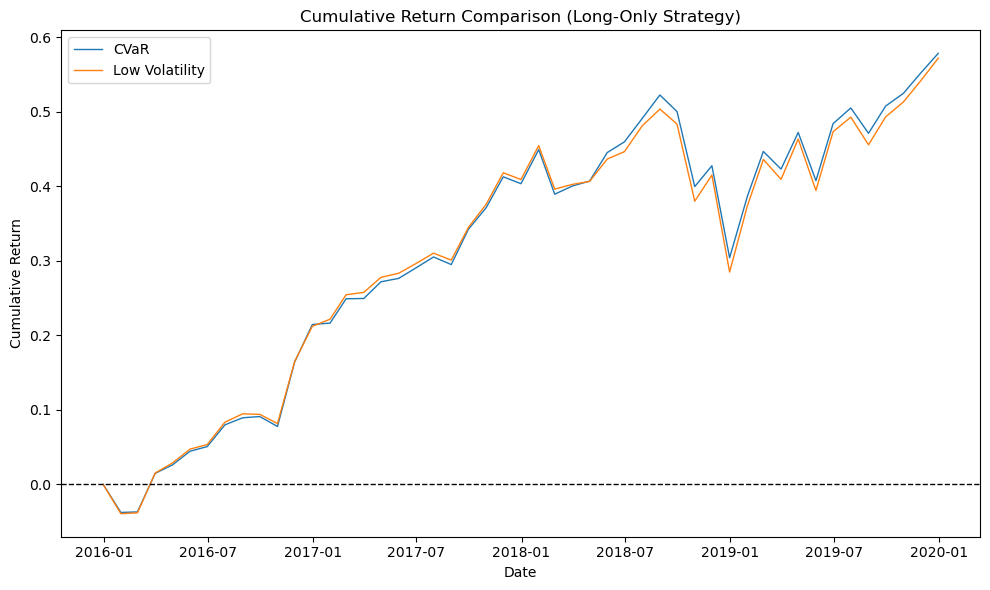

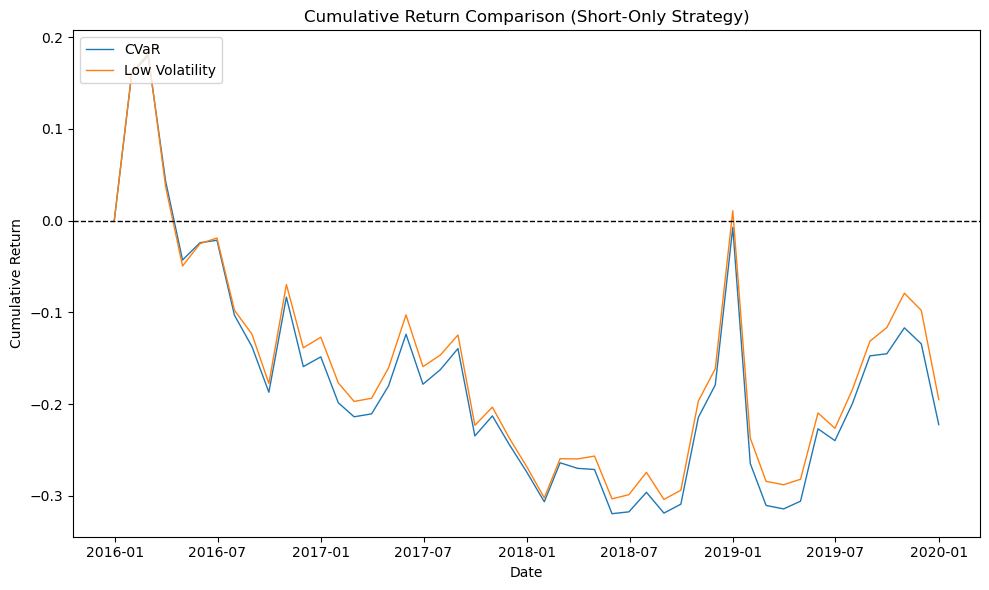

In [76]:
for strategy in ['long_short', 'long_only', 'short_only']:
    # Calculte CVaR cumulative returns
    cvar_rets = port_rets_dict[('tail_score', strategy)].loc[start_date:end_date]
    cvar_cum_rets = (1 + cvar_rets).cumprod() - 1
    cvar_cum_rets = pd.concat([pd.Series([0], index=[cvar_rets.index[0] - pd.DateOffset(months=1)]), cvar_cum_rets])

    # Calculate benchmark cumulative returns
    vol_rets = port_rets_dict[('vol', strategy)].loc[start_date:end_date]
    vol_cum_rets = (1 + vol_rets).cumprod() - 1
    vol_cum_rets = pd.concat([pd.Series([0], index=[vol_rets.index[0] - pd.DateOffset(months=1)]), vol_cum_rets])

    # Compare both cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cvar_cum_rets.index, cvar_cum_rets, label='CVaR', linewidth=1)
    plt.plot(vol_cum_rets.index, vol_cum_rets, label='Low Volatility', linewidth=1)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Return Comparison ({strategy.replace("_", "-").title()} Strategy)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

#### 9.2. Regime 2 (2020-2022)

In [77]:
start_date = '2020-01-31'
end_date = '2022-12-31'

# Compare performance across different strategies and factors
for strategy in ['long_short', 'long_only', 'short_only']:
    for factor in ['tail_score', 'vol']:
        port_rets = port_rets_dict[(factor, strategy)]
        port_rets = port_rets.loc[start_date:end_date]
        summarize_performance(port_rets, factor=factor, strategy=strategy)

Performance Summary:
Factor:                tail_score
Strategy:              long_short
Sample period:         2020-01 to 2022-12
Number of months:      36
Mean monthly return:   -0.25%
Annualized return:     -3.03%
Monthly stdev:         11.17%
Annualized stdev:      38.70%
T-statistic:           -0.14
Sharpe ratio:          -0.08
Cumulative return:     -28.10%
Max drawdown:          -74.30%

Performance Summary:
Factor:                vol
Strategy:              long_short
Sample period:         2020-01 to 2022-12
Number of months:      36
Mean monthly return:   -0.53%
Annualized return:     -6.35%
Monthly stdev:         11.80%
Annualized stdev:      40.86%
T-statistic:           -0.27
Sharpe ratio:          -0.16
Cumulative return:     -37.21%
Max drawdown:          -76.75%

Performance Summary:
Factor:                tail_score
Strategy:              long_only
Sample period:         2020-01 to 2022-12
Number of months:      36
Mean monthly return:   0.62%
Annualized return:     7.4

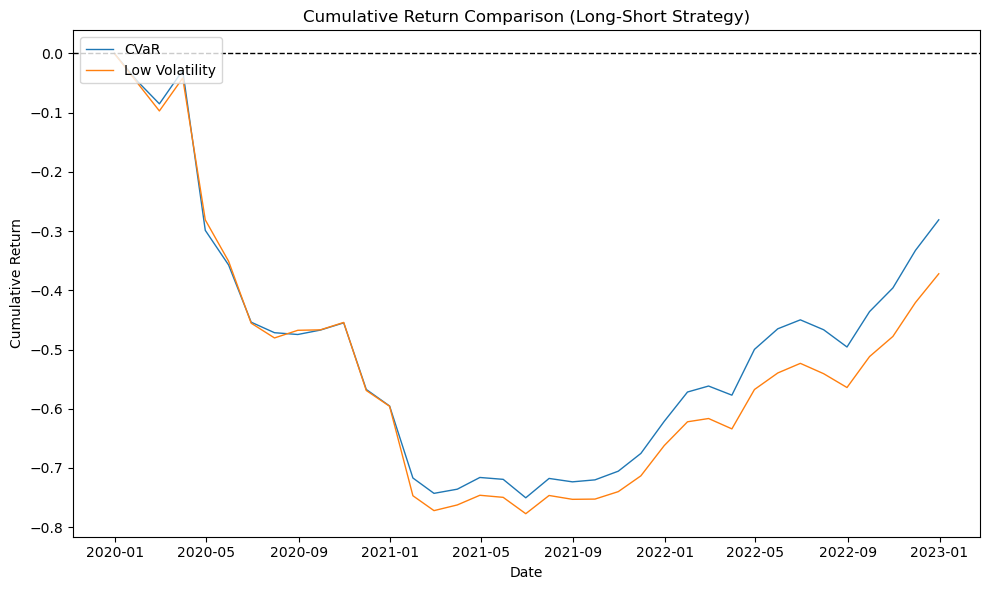

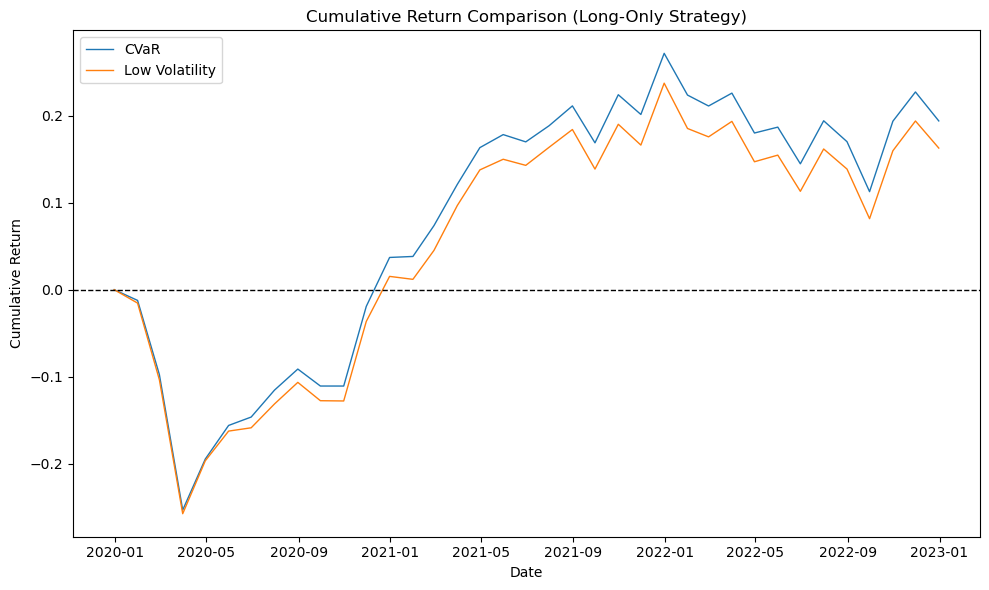

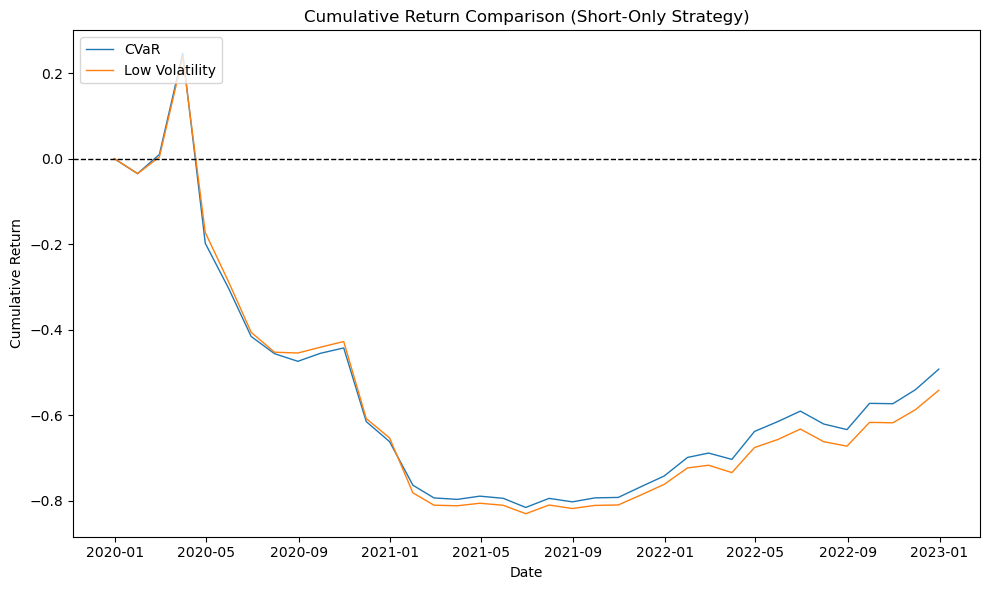

In [78]:
for strategy in ['long_short', 'long_only', 'short_only']:
    # Calculte CVaR cumulative returns
    cvar_rets = port_rets_dict[('tail_score', strategy)].loc[start_date:end_date]
    cvar_cum_rets = (1 + cvar_rets).cumprod() - 1
    cvar_cum_rets = pd.concat([pd.Series([0], index=[cvar_rets.index[0] - pd.DateOffset(months=1)]), cvar_cum_rets])

    # Calculate benchmark cumulative returns
    vol_rets = port_rets_dict[('vol', strategy)].loc[start_date:end_date]
    vol_cum_rets = (1 + vol_rets).cumprod() - 1
    vol_cum_rets = pd.concat([pd.Series([0], index=[vol_rets.index[0] - pd.DateOffset(months=1)]), vol_cum_rets])

    # Compare both cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cvar_cum_rets.index, cvar_cum_rets, label='CVaR', linewidth=1)
    plt.plot(vol_cum_rets.index, vol_cum_rets, label='Low Volatility', linewidth=1)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Return Comparison ({strategy.replace("_", "-").title()} Strategy)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

#### 9.3. Regime 3 (2023-2024)

In [79]:
start_date = '2023-01-31'
end_date = '2024-12-31'

# Compare performance across different strategies and factors
for strategy in ['long_short', 'long_only', 'short_only']:
    for factor in ['tail_score', 'vol']:
        port_rets = port_rets_dict[(factor, strategy)]
        port_rets = port_rets.loc[start_date:end_date]
        summarize_performance(port_rets, factor=factor, strategy=strategy)

Performance Summary:
Factor:                tail_score
Strategy:              long_short
Sample period:         2023-01 to 2024-12
Number of months:      24
Mean monthly return:   1.23%
Annualized return:     14.74%
Monthly stdev:         9.10%
Annualized stdev:      31.53%
T-statistic:           0.66
Sharpe ratio:          0.47
Cumulative return:     20.89%
Max drawdown:          -12.22%

Performance Summary:
Factor:                vol
Strategy:              long_short
Sample period:         2023-01 to 2024-12
Number of months:      24
Mean monthly return:   1.24%
Annualized return:     14.84%
Monthly stdev:         8.94%
Annualized stdev:      30.98%
T-statistic:           0.68
Sharpe ratio:          0.48
Cumulative return:     21.76%
Max drawdown:          -12.88%

Performance Summary:
Factor:                tail_score
Strategy:              long_only
Sample period:         2023-01 to 2024-12
Number of months:      24
Mean monthly return:   0.65%
Annualized return:     7.81%
Monthly

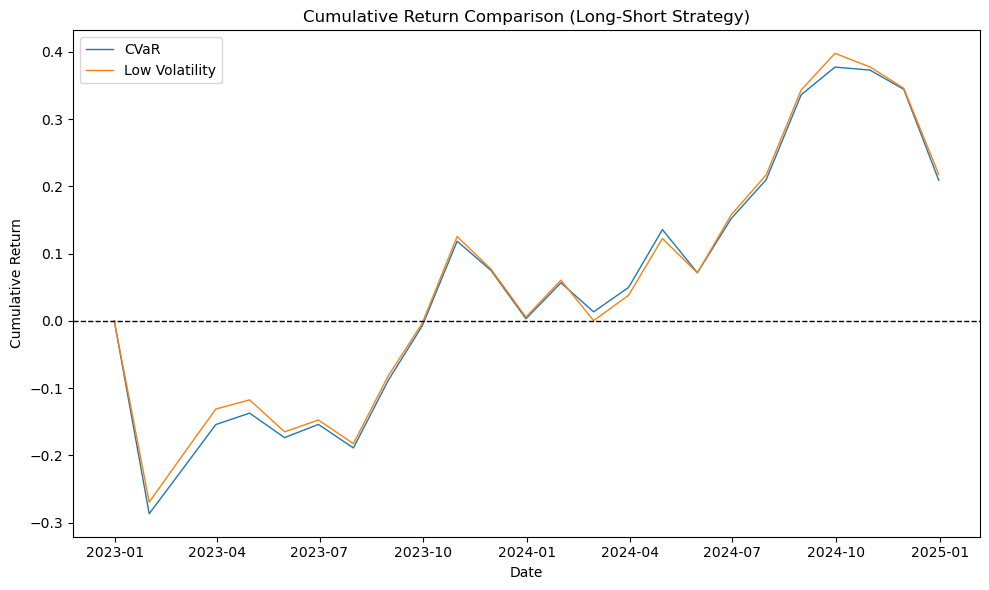

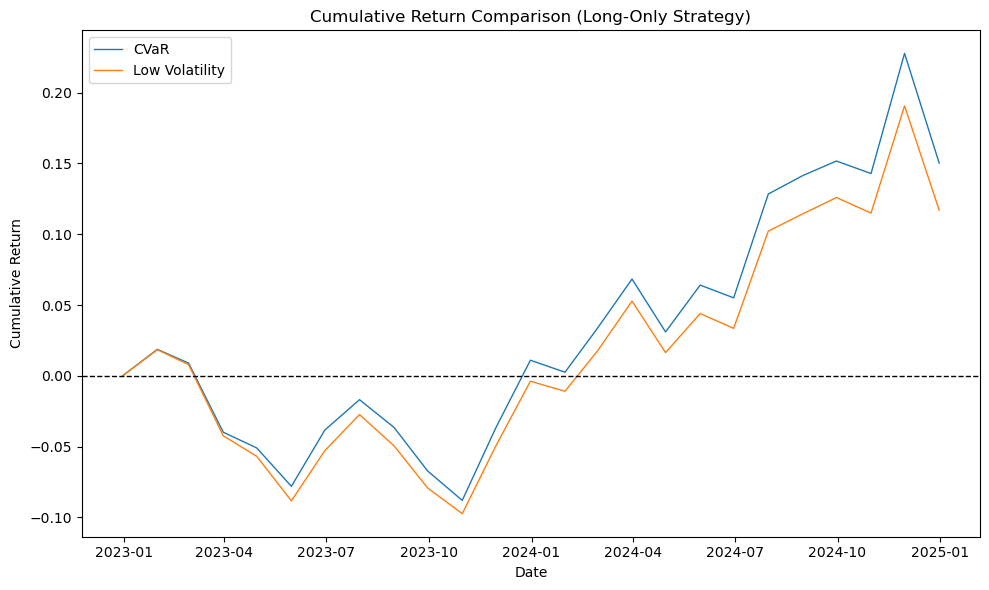

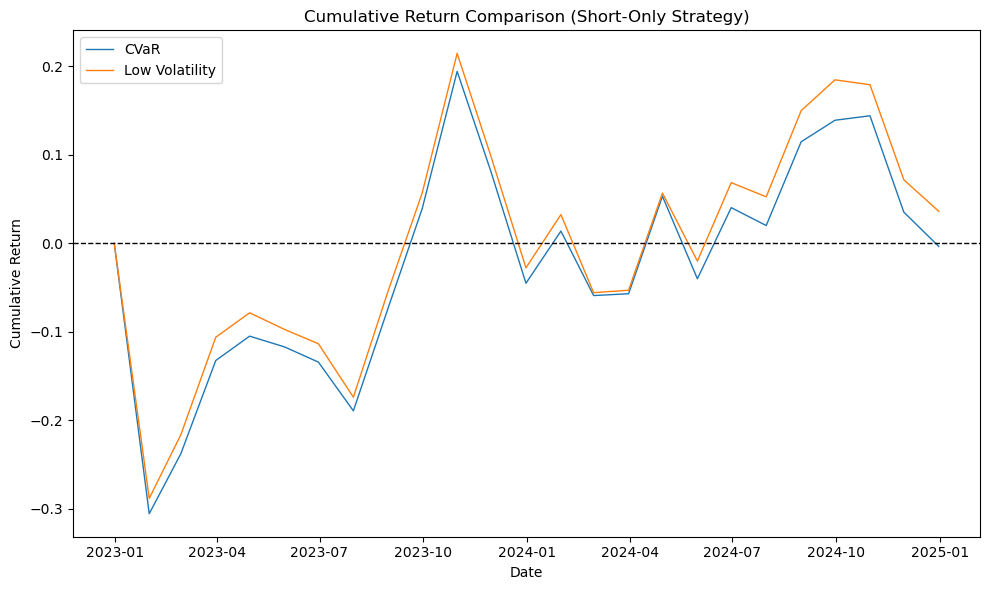

In [80]:
for strategy in ['long_short', 'long_only', 'short_only']:
    # Calculte CVaR cumulative returns
    cvar_rets = port_rets_dict[('tail_score', strategy)].loc[start_date:end_date]
    cvar_cum_rets = (1 + cvar_rets).cumprod() - 1
    cvar_cum_rets = pd.concat([pd.Series([0], index=[cvar_rets.index[0] - pd.DateOffset(months=1)]), cvar_cum_rets])

    # Calculate benchmark cumulative returns
    vol_rets = port_rets_dict[('vol', strategy)].loc[start_date:end_date]
    vol_cum_rets = (1 + vol_rets).cumprod() - 1
    vol_cum_rets = pd.concat([pd.Series([0], index=[vol_rets.index[0] - pd.DateOffset(months=1)]), vol_cum_rets])

    # Compare both cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cvar_cum_rets.index, cvar_cum_rets, label='CVaR', linewidth=1)
    plt.plot(vol_cum_rets.index, vol_cum_rets, label='Low Volatility', linewidth=1)
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Return Comparison ({strategy.replace("_", "-").title()} Strategy)')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()